In [1]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
from sqlalchemy import create_engine, inspect, text
from IPython.display import display

In [2]:
# Relative path of db
db_path = Path.cwd().parent / "data" / "gas_monitoring.db"

In [3]:
# Convert full path to a string
engine = create_engine(f"sqlite:///{db_path.resolve()}")

In [4]:
# Check if successful
inspector = inspect(engine)
# Check only 1 table
if len(inspector.get_table_names()) == 1:
    print("Table found:", inspector.get_table_names()[0])
    table_name = inspector.get_table_names()[0]
else:
    print("Incorrect amount of tables found")

Table found: gas_monitoring


In [5]:
# Check amount of rows in database
with engine.connect() as connection:
    query = text(f"SELECT COUNT(*) FROM {table_name};")
    db_rows = connection.execute(query).scalar()

print(f" Total rows: {db_rows:,}")

 Total rows: 10,000


In [6]:
# Pull table
df = pd.read_sql_table(table_name, engine)
print(f"Loaded {len(df)} rows into memory.")

Loaded 10000 rows into memory.


In [7]:
df.head()

,Time of Day,Temperature,Humidity,CO2_InfraredSensor,CO2_ElectroChemicalSensor,MetalOxideSensor_Unit1,MetalOxideSensor_Unit2,MetalOxideSensor_Unit3,MetalOxideSensor_Unit4,CO_GasSensor,Session ID,HVAC Operation Mode,Ambient Light Level,Activity Level
0,morning,19.63,53.83,125.486389,571.089440,478.554958,735.850412,654.625253,565.051969,2.0,7241,off,very_dim,Low Activity
1,morning,292.81,53.69,126.343018,575.789501,491.955151,740.282738,655.734327,557.078486,1.0,7241,ventilation_only,bright,Low Activity
2,morning,19.62,54.25,126.560695,585.543111,505.560808,737.112906,649.962421,558.065196,1.0,7241,eco_mode,None,Low Activity
3,morning,20.10,50.48,113.504877,597.449961,515.142272,744.020651,676.150075,600.222210,NaN,7241,eco_mode,very_bright,High Activity
4,morning,19.89,48.42,92.766225,613.654875,535.664558,770.265441,720.274019,625.731124,1.0,7241,heating_active,moderate,LowActivity


In [8]:
df.shape

(10000, 14)

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Time of Day                10000 non-null  object 
 1   Temperature                10000 non-null  float64
 2   Humidity                   8072 non-null   float64
 3   CO2_InfraredSensor         10000 non-null  float64
 4   CO2_ElectroChemicalSensor  10000 non-null  float64
 5   MetalOxideSensor_Unit1     10000 non-null  float64
 6   MetalOxideSensor_Unit2     8590 non-null   float64
 7   MetalOxideSensor_Unit3     10000 non-null  float64
 8   MetalOxideSensor_Unit4     10000 non-null  float64
 9   CO_GasSensor               9166 non-null   float64
 10  Session ID                 10000 non-null  int64  
 11  HVAC Operation Mode        10000 non-null  object 
 12  Ambient Light Level        8946 non-null   object 
 13  Activity Level             10000 non-null  obje

In [10]:
# number of empty cells per column
df.isnull().sum()

Time of Day                     0
Temperature                     0
Humidity                     1928
CO2_InfraredSensor              0
CO2_ElectroChemicalSensor       0
MetalOxideSensor_Unit1          0
MetalOxideSensor_Unit2       1410
MetalOxideSensor_Unit3          0
MetalOxideSensor_Unit4          0
CO_GasSensor                  834
Session ID                      0
HVAC Operation Mode             0
Ambient Light Level          1054
Activity Level                  0
dtype: int64

Empty cells are in 4 columns: humidity, metal oxide sensor 2, co gas sensor, and ambient light level

In [11]:
def show_null_rows(column_name, df=df):
    """
    Prints the entire row for missing values in the specified column in specified dataframe
    """
    display(df[df[column_name].isna()])

In [12]:
show_null_rows("Humidity")

,Time of Day,Temperature,Humidity,CO2_InfraredSensor,CO2_ElectroChemicalSensor,MetalOxideSensor_Unit1,MetalOxideSensor_Unit2,MetalOxideSensor_Unit3,MetalOxideSensor_Unit4,CO_GasSensor,Session ID,HVAC Operation Mode,Ambient Light Level,Activity Level
15,morning,18.53,NaN,80.148375,590.702934,596.654594,765.694890,750.303681,700.075087,0.0,1903,heating_active,very_bright,Low Activity
25,afternoon,19.46,NaN,81.850351,616.549883,538.974555,764.222091,488.808765,625.088579,1.0,7241,maintenance_mode,very_dim,Low Activity
30,afternoon,20.52,NaN,88.131804,614.973747,506.676587,755.728581,689.985534,611.737822,NaN,7241,cooling_active,bright,Moderate Activity
36,afternoon,20.68,NaN,82.119635,618.282123,428.657481,764.534299,718.546551,637.902211,1.0,7241,cooling_active,very_bright,Moderate Activity
38,morning,19.64,NaN,139.902168,579.301906,476.971294,720.978887,682.696743,607.577312,1.0,4507,off,dim,Moderate Activity
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9971,afternoon,17.31,NaN,94.323686,594.188754,461.426538,726.681435,693.159035,628.618046,2.0,2679,cooling_active,None,Moderate Activity
9979,night,21.33,NaN,134.623928,553.641599,414.279896,694.386273,651.722779,572.288211,2.0,4761,eco_mode,None,Low Activity
9993,morning,16.84,NaN,121.589332,589.097836,502.213084,762.497500,562.849426,669.410300,0.0,5820,eco_mode,bright,Low Activity
9995,evening,23.45,NaN,137.854649,544.124855,510.926349,NaN,680.916215,620.292682,1.0,2586,maintenance_mode,very_bright,Low Activity


In [13]:
show_null_rows("MetalOxideSensor_Unit2")

,Time of Day,Temperature,Humidity,CO2_InfraredSensor,CO2_ElectroChemicalSensor,MetalOxideSensor_Unit1,MetalOxideSensor_Unit2,MetalOxideSensor_Unit3,MetalOxideSensor_Unit4,CO_GasSensor,Session ID,HVAC Operation Mode,Ambient Light Level,Activity Level
12,morning,17.79,51.15,116.555038,590.747488,456.426736,NaN,691.308364,609.604835,1.0,3418,ventilation_only,None,Moderate Activity
23,morning,19.25,54.37,-2.548722,574.748934,496.938842,NaN,701.422404,638.826368,NaN,1826,ventilation_only,very_bright,Moderate Activity
28,afternoon,295.04,51.34,115.203695,571.393272,499.873896,NaN,802.571265,575.355790,2.0,4761,ventilation_only,very_bright,Low Activity
35,evening,24.02,48.39,128.692361,539.592438,386.797276,NaN,543.856834,477.859881,4.0,7058,maintenance_mode,bright,Low Activity
49,afternoon,22.99,51.07,116.780904,532.683719,402.180211,NaN,615.559061,534.378179,4.0,4703,COOLING_ACTIVE,bright,Low Activity
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9967,evening,24.27,NaN,214.848164,573.884352,406.396707,NaN,635.031047,543.226050,NaN,7395,cooling_active,None,Low_Activity
9977,evening,22.85,46.80,119.371474,586.565204,422.759013,NaN,673.232204,625.357845,2.0,9658,maintenance_mode,very_bright,High Activity
9983,afternoon,23.00,152.46,116.846743,577.424852,460.276579,NaN,675.221322,601.178927,1.0,4507,maintenance_mode,moderate,High Activity
9992,evening,22.92,46.64,119.253573,550.549792,495.301121,NaN,685.680572,619.343335,1.0,2586,heating_active,bright,High Activity


In [14]:
show_null_rows("CO_GasSensor")

,Time of Day,Temperature,Humidity,CO2_InfraredSensor,CO2_ElectroChemicalSensor,MetalOxideSensor_Unit1,MetalOxideSensor_Unit2,MetalOxideSensor_Unit3,MetalOxideSensor_Unit4,CO_GasSensor,Session ID,HVAC Operation Mode,Ambient Light Level,Activity Level
3,morning,20.10,50.48,113.504877,597.449961,515.142272,744.020651,676.150075,600.222210,NaN,7241,eco_mode,very_bright,High Activity
9,night,19.81,-48.34,8.964022,595.833260,464.828130,737.958044,687.714744,622.836602,NaN,2105,ventilation_only,None,Low Activity
19,afternoon,19.57,51.23,91.168499,611.561714,537.713012,751.668484,709.823944,621.493028,NaN,7241,maintenance_mode,very_bright,Moderate Activity
23,morning,19.25,54.37,-2.548722,574.748934,496.938842,NaN,701.422404,638.826368,NaN,1826,ventilation_only,very_bright,Moderate Activity
27,morning,292.17,50.12,79.585071,614.239997,517.352383,762.802020,549.291994,667.030718,NaN,3856,ventilation_only,very_bright,Moderate Activity
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9954,afternoon,293.94,44.55,75.618247,567.044186,511.008803,753.665230,718.474331,664.598081,NaN,2586,eco_mode,very_bright,Moderate Activity
9964,afternoon,21.69,44.71,81.385283,561.968352,527.330609,752.324424,718.379962,659.181524,NaN,2586,Heating_Active,very_dim,Low Activity
9967,evening,24.27,NaN,214.848164,573.884352,406.396707,NaN,635.031047,543.226050,NaN,7395,cooling_active,None,Low_Activity
9980,night,292.01,52.10,118.519591,587.887196,464.160197,748.870053,712.972441,642.839403,NaN,9658,off,very_bright,ModerateActivity


In [15]:
show_null_rows("Ambient Light Level")

,Time of Day,Temperature,Humidity,CO2_InfraredSensor,CO2_ElectroChemicalSensor,MetalOxideSensor_Unit1,MetalOxideSensor_Unit2,MetalOxideSensor_Unit3,MetalOxideSensor_Unit4,CO_GasSensor,Session ID,HVAC Operation Mode,Ambient Light Level,Activity Level
2,morning,19.62,54.25,126.560695,585.543111,505.560808,737.112906,649.962421,558.065196,1.0,7241,eco_mode,None,Low Activity
9,night,19.81,-48.34,8.964022,595.833260,464.828130,737.958044,687.714744,622.836602,NaN,2105,ventilation_only,None,Low Activity
11,afternoon,19.71,48.68,80.161332,615.972458,575.491588,780.078308,732.349009,667.927995,0.0,7241,eco_mode,None,ModerateActivity
12,morning,17.79,51.15,116.555038,590.747488,456.426736,NaN,691.308364,609.604835,1.0,3418,ventilation_only,None,Moderate Activity
17,afternoon,19.73,50.62,91.736107,619.342912,527.869881,761.418621,703.674613,618.386499,0.0,7241,Heating_active,None,High Activity
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9967,evening,24.27,NaN,214.848164,573.884352,406.396707,NaN,635.031047,543.226050,NaN,7395,cooling_active,None,Low_Activity
9971,afternoon,17.31,NaN,94.323686,594.188754,461.426538,726.681435,693.159035,628.618046,2.0,2679,cooling_active,None,Moderate Activity
9976,night,20.99,57.61,-9.992761,561.460188,446.620844,703.945003,663.041519,578.163559,1.0,4761,Maintenance_mode,None,Low Activity
9979,night,21.33,NaN,134.623928,553.641599,414.279896,694.386273,651.722779,572.288211,2.0,4761,eco_mode,None,Low Activity


Initial inspection of missing values do not show any obvious reasons, will examine non-missing data first before deciding on what to do

In [16]:
# number of duplicate rows
df.duplicated().sum()

171

In [17]:
# inspect duplicate rows
df[df.duplicated()]

,Time of Day,Temperature,Humidity,CO2_InfraredSensor,CO2_ElectroChemicalSensor,MetalOxideSensor_Unit1,MetalOxideSensor_Unit2,MetalOxideSensor_Unit3,MetalOxideSensor_Unit4,CO_GasSensor,Session ID,HVAC Operation Mode,Ambient Light Level,Activity Level
493,evening,23.52,43.25,88.690954,603.702902,496.306607,747.498224,702.297867,630.522057,1.0,5693,heating_active,bright,Moderate Activity
1097,morning,18.99,55.92,118.637160,600.695160,502.885955,735.720000,703.310462,615.349296,1.0,5693,ventilation_only,bright,High Activity
1252,evening,24.06,44.04,105.264563,598.388502,496.349041,735.360708,703.337182,629.341589,1.0,8374,off,moderate,Moderate Activity
1491,morning,17.37,44.26,60.765226,621.136492,602.596911,800.021351,754.924569,722.835228,0.0,5693,off,moderate,Moderate Activity
1576,night,20.77,NaN,105.027749,600.128419,469.521450,738.124661,686.433295,612.079199,2.0,8374,ventilation_only,bright,Moderate Activity
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9784,morning,19.56,46.23,82.165104,618.878313,547.258686,774.347295,746.520275,688.083021,0.0,5693,maintenance_mode,bright,Low Activity
9812,afternoon,19.45,53.78,127.170465,568.974112,416.661925,718.673151,686.167655,621.327160,1.0,3074,ventilation_only,very_bright,High Activity
9902,night,18.08,54.39,118.473630,587.984997,506.368702,739.635625,698.921105,617.032041,1.0,9658,cooling_active,moderate,Low Activity
9946,evening,25.70,48.15,121.606097,539.641062,484.896859,675.467858,594.954642,537.075883,2.0,6817,maintenance_mode,moderate,Moderate Activity


Duplicate rows seem to be duplicated at random

In [18]:
# remove duplicate rows without creating new df
df.drop_duplicates(inplace=True)
df.shape

(9829, 14)

Moving on to inspection of values in individual columns

Time of Day Column

In [19]:
# values in time of day column
df["Time of Day"].value_counts()

Time of Day
afternoon    2586
evening      2432
morning      2415
night        2396
Name: count, dtype: int64

Temperature Column (WIP)

In [20]:
def plot_scatter(values, x_axis=None):
    """
    Plots a scatter graph of values
    Uses x axis if provided, otherwise defaults to the index of the values
    """
    plt.figure(figsize=(10, 5))
    # if no x_axis is provided, use list index
    x = x_axis if x_axis is not None else range(len(values))
    plt.scatter(x, values, alpha=0.7)
    plt.grid(True, alpha=0.3)
    plt.show()

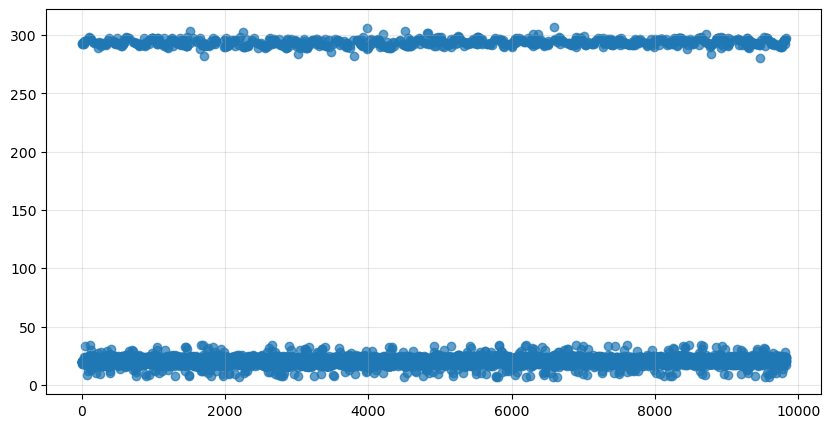

count    9829.000000
mean       42.618136
std        74.559993
min         6.903485
25%        18.930000
50%        20.510000
75%        23.180000
max       307.070000
Name: Temperature, dtype: float64

In [21]:
# Visualise and show distribution of temperature readings
plot_scatter(df["Temperature"])
df["Temperature"].describe()

min and max values are abnormal

In [22]:
# inspect abnormally high values
display(df[df["Temperature"] > 50])

,Time of Day,Temperature,Humidity,CO2_InfraredSensor,CO2_ElectroChemicalSensor,MetalOxideSensor_Unit1,MetalOxideSensor_Unit2,MetalOxideSensor_Unit3,MetalOxideSensor_Unit4,CO_GasSensor,Session ID,HVAC Operation Mode,Ambient Light Level,Activity Level
1,morning,292.81,53.69,126.343018,575.789501,491.955151,740.282738,655.734327,557.078486,1.0,7241,ventilation_only,bright,Low Activity
8,afternoon,292.59,47.92,74.100322,624.577270,564.745091,798.290403,753.467986,674.278245,0.0,7241,maintenance_mode,very_bright,Low Activity
24,afternoon,292.65,51.95,84.581085,617.316915,534.905951,767.204960,717.770588,617.513808,1.0,7241,eco_mode,very_bright,Moderate Activity
27,morning,292.17,50.12,79.585071,614.239997,517.352383,762.802020,549.291994,667.030718,NaN,3856,ventilation_only,very_bright,Moderate Activity
28,afternoon,295.04,51.34,115.203695,571.393272,499.873896,NaN,802.571265,575.355790,2.0,4761,ventilation_only,very_bright,Low Activity
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9980,night,292.01,52.10,118.519591,587.887196,464.160197,748.870053,712.972441,642.839403,NaN,9658,off,very_bright,ModerateActivity
9981,evening,295.61,45.84,85.732048,559.357007,511.585673,749.994773,704.264333,647.845091,1.0,2586,eco_mode,moderate,Moderate Activity
9982,evening,295.67,45.89,91.771848,552.961200,515.944782,751.423006,713.109219,653.457688,1.0,2586,maintenance_mode,very_dim,High Activity
9989,night,296.17,49.35,119.874350,571.897844,413.811232,711.960225,673.048526,589.516066,2.0,1826,ventilation_only,None,Low Activity


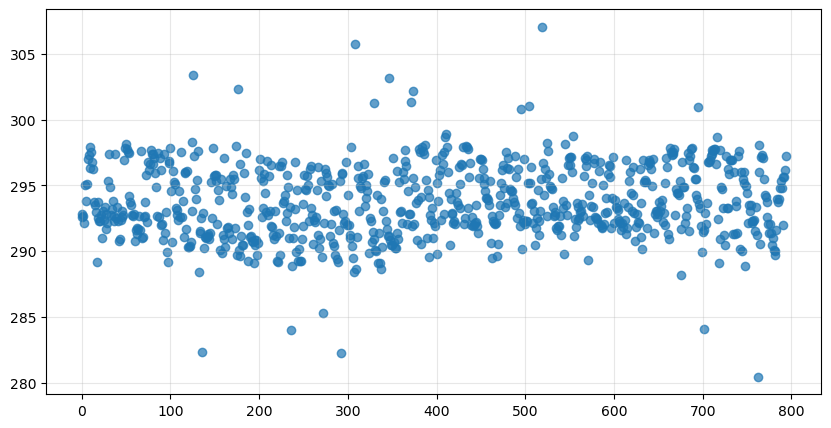

count    795.000000
mean     293.760981
std        2.789414
min      280.450000
25%      291.925000
50%      293.360000
75%      295.870000
max      307.070000
Name: Temperature, dtype: float64

In [23]:
# visualise temperature above 50
plot_scatter(df[df["Temperature"] > 50]["Temperature"])
df[df["Temperature"] > 50]["Temperature"].describe()

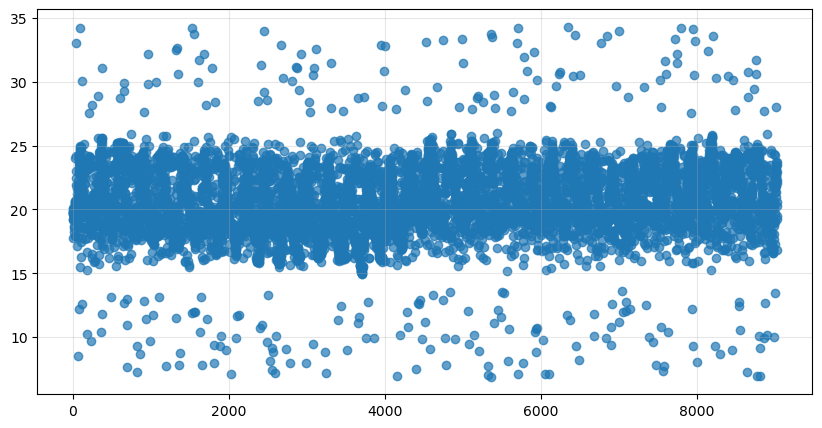

In [24]:
plot_scatter(df[df["Temperature"] < 50]["Temperature"])

Assuming that the abnormally high temperature values are 10x what they should be

In [25]:
# divide all temperatures above 50 by 10
df.loc[df['Temperature'] > 50, 'Temperature'] /= 10

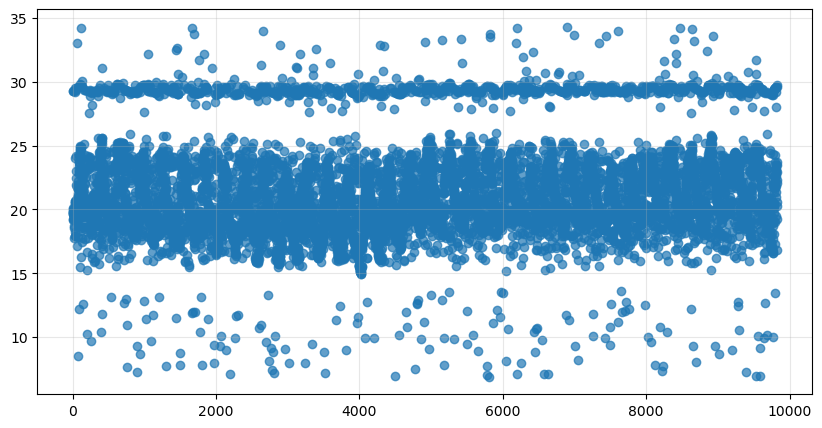

In [26]:
# visualise updated temperature readings
plot_scatter(df["Temperature"])

In [27]:
# inspect high temperature values
df[df["Temperature"] > 30]

,Time of Day,Temperature,Humidity,CO2_InfraredSensor,CO2_ElectroChemicalSensor,MetalOxideSensor_Unit1,MetalOxideSensor_Unit2,MetalOxideSensor_Unit3,MetalOxideSensor_Unit4,CO_GasSensor,Session ID,HVAC Operation Mode,Ambient Light Level,Activity Level
54,morning,33.041318,51.67,105.630998,596.534869,486.448341,747.038731,712.401956,628.500943,1.0,8374,cooling_active,moderate,High Activity
111,evening,34.239708,NaN,118.441217,595.729435,452.272956,723.133913,485.407246,592.647198,2.0,7241,Maintenance_Mode,very_bright,Low_Activity
133,evening,30.060079,52.67,118.153494,599.747325,421.326002,711.865910,652.665558,591.103827,3.0,7241,eco_mode,very_bright,Low_Activity
407,afternoon,31.100551,52.83,118.288369,552.688992,462.830697,681.298560,600.175993,544.795447,2.0,7058,heating_active,None,Low Activity
1055,evening,32.197490,47.23,105.385537,591.210696,474.922904,739.474129,684.811562,611.941445,1.0,9658,eco_mode,very_bright,Low_Activity
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9291,afternoon,30.466123,52.05,117.532450,539.323051,474.100402,711.941508,669.027852,602.710548,2.0,1458,cooling_active,very_bright,Low_Activity
9358,afternoon,30.142086,125.88,116.780904,532.683719,402.180211,705.410192,615.559061,534.378179,4.0,4703,cooling_active,bright,Low Activity
9579,morning,30.779348,50.17,100.064692,550.161557,458.934474,725.118787,639.296548,574.862978,2.0,4703,off,very_bright,Low Activity
9691,evening,31.677019,48.76,103.291036,551.113497,443.834025,732.176971,688.450618,617.830907,1.0,4703,ventilation_only,bright,Moderate Activity


In [28]:
df[df["Temperature"] > 30]["Time of Day"].value_counts()

Time of Day
morning      27
afternoon    19
evening      17
night        15
Name: count, dtype: int64

In [29]:
# inspect low temperature values
df[df["Temperature"] < 15]

,Time of Day,Temperature,Humidity,CO2_InfraredSensor,CO2_ElectroChemicalSensor,MetalOxideSensor_Unit1,MetalOxideSensor_Unit2,MetalOxideSensor_Unit3,MetalOxideSensor_Unit4,CO_GasSensor,Session ID,HVAC Operation Mode,Ambient Light Level,Activity Level
80,evening,8.499293,51.84,104.237654,609.733706,473.936972,NaN,676.306256,608.415572,1.0,7241,heating_active,bright,Low Activity
89,night,12.229653,47.32,111.790594,577.632466,444.180853,723.045899,696.629900,611.205888,2.0,6431,heating_active,very_bright,Low Activity
137,night,12.614772,52.79,115.635688,550.871360,471.867654,697.028391,636.657652,571.409105,1.0,6817,off,bright,Low Activity
198,night,10.233207,56.94,111.733666,591.270244,458.709013,728.708661,859.125193,612.345406,3.0,7241,heating_active,None,Low Activity
252,morning,9.691520,48.13,81.914994,612.981958,545.951108,768.793812,745.684560,664.890366,2.0,3856,ventilation_only,very_bright,Moderate Activity
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9804,night,9.902174,NaN,93.863652,559.891665,489.564057,749.978097,542.993713,632.326626,1.0,9241,ventilation_only,very_bright,High Activity
9826,morning,12.702877,50.07,62.835035,614.971921,586.409119,781.033651,751.944760,693.920387,NaN,4129,eco_mode,moderate,Moderate Activity
9849,evening,10.152654,47.09,113.662748,586.588217,425.938439,743.931645,699.069839,636.930028,1.0,5820,off,very_dim,Moderate Activity
9943,afternoon,10.032879,44.70,64.945329,572.230665,547.016366,781.940559,563.421191,698.455061,0.0,2586,heating_active,very_bright,Moderate Activity


decide what to do with low temperature readings

Humidity Column (WIP)

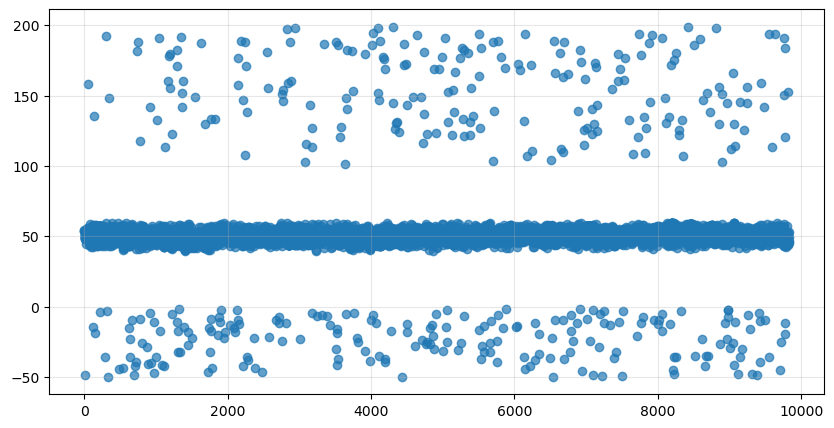

count    7912.000000
mean       51.653645
std        21.540837
min       -49.870000
25%        47.650000
50%        51.380000
75%        53.832500
max       198.900000
Name: Humidity, dtype: float64

In [30]:
# Visualise and show distribution of humidity readings
plot_scatter(df["Humidity"])
df["Humidity"].describe()

Values above 100 and below 0 are impossible for humidity percentage

In [31]:
# inspect abnormal values
df[(df["Humidity"] > 100) | (df["Humidity"] < 0)]

,Time of Day,Temperature,Humidity,CO2_InfraredSensor,CO2_ElectroChemicalSensor,MetalOxideSensor_Unit1,MetalOxideSensor_Unit2,MetalOxideSensor_Unit3,MetalOxideSensor_Unit4,CO_GasSensor,Session ID,HVAC Operation Mode,Ambient Light Level,Activity Level
9,night,19.810,-48.34,8.964022,595.833260,464.828130,737.958044,687.714744,622.836602,NaN,2105,ventilation_only,None,Low Activity
50,afternoon,20.190,158.33,89.470910,620.364794,405.071346,747.384712,698.477480,621.003407,1.0,7241,heating_active,None,Low Activity
120,night,18.570,-14.79,121.184923,579.703970,468.239926,NaN,678.065464,620.466497,1.0,2679,cooling_active,very_bright,Moderate Activity
128,evening,22.730,135.21,125.466163,591.519617,414.920829,714.063935,660.222162,578.452856,3.0,7241,heating_active,very_bright,Low Activity
146,night,19.690,-18.73,120.017584,549.422635,459.086470,692.412305,645.741758,571.745341,2.0,7058,off,bright,Low Activity
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9942,afternoon,18.670,183.84,180.176445,572.653896,563.034853,781.939704,728.174809,697.167548,0.0,2586,maintenance_mode,very_bright,Low Activity
9945,afternoon,19.090,-11.60,73.710835,572.395364,548.852905,781.012720,743.040666,680.972017,0.0,2586,eco_mode,bright,Moderate Activity
9947,afternoon,20.290,-19.31,78.494846,560.663225,428.938003,741.508039,690.496168,645.853640,0.0,2586,off,bright,Low Activity
9950,afternoon,29.399,120.33,68.815941,566.245679,484.518300,754.121435,708.360447,666.830387,1.0,2586,off,very_bright,Low Activity


Decide what to do with outlier humidity values

CO2_InfraredSensor Column (WIP)

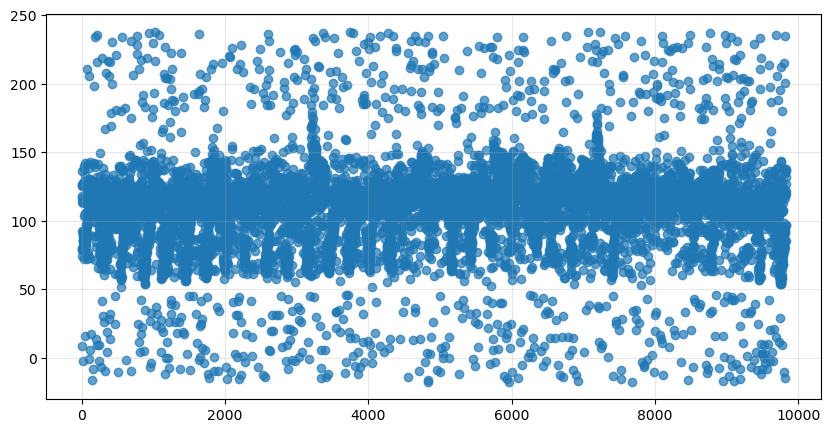

count    9829.000000
mean      109.848163
std        33.981285
min       -17.472184
25%        96.535194
50%       112.803655
75%       124.563798
max       237.873938
Name: CO2_InfraredSensor, dtype: float64

In [32]:
plot_scatter(df["CO2_InfraredSensor"])
df["CO2_InfraredSensor"].describe()

In [33]:
df[(df["CO2_InfraredSensor"] > 200) | (df["CO2_InfraredSensor"] < 0)]

,Time of Day,Temperature,Humidity,CO2_InfraredSensor,CO2_ElectroChemicalSensor,MetalOxideSensor_Unit1,MetalOxideSensor_Unit2,MetalOxideSensor_Unit3,MetalOxideSensor_Unit4,CO_GasSensor,Session ID,HVAC Operation Mode,Ambient Light Level,Activity Level
23,morning,19.25,54.37,-2.548722,574.748934,496.938842,NaN,701.422404,638.826368,NaN,1826,ventilation_only,very_bright,Moderate Activity
81,morning,19.81,58.73,210.936386,550.024240,497.946800,NaN,600.784988,541.389787,NaN,8936,heating_active,bright,Low Activity
100,morning,15.48,42.19,205.484167,605.228667,582.396453,787.194813,754.069349,704.616559,1.0,8052,cooling_active,moderate,Low Activity
101,evening,24.94,46.56,-1.146669,605.868070,475.340247,726.618627,681.717422,598.765948,1.0,7241,off,moderate,Moderate Activity
143,morning,19.54,55.70,-16.122085,562.727918,475.855521,738.540879,691.220608,634.500030,1.0,2847,cooling_active,bright,Moderate Activity
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9967,evening,24.27,NaN,214.848164,573.884352,406.396707,NaN,635.031047,543.226050,NaN,7395,cooling_active,None,Low_Activity
9976,night,20.99,57.61,-9.992761,561.460188,446.620844,703.945003,663.041519,578.163559,1.0,4761,Maintenance_mode,None,Low Activity
9984,evening,23.48,44.08,200.468863,562.455946,527.358322,747.075654,709.220197,647.675453,1.0,2586,eco_mode,moderate,Low Activity
9986,evening,23.16,44.96,-15.001692,559.858738,505.954916,743.344164,692.204081,631.571948,1.0,2586,off,very_bright,Low Activity


Cross reference infrared sensor with electrochemical sensor

CO2_ElectroChemicalSensor Column (WIP)

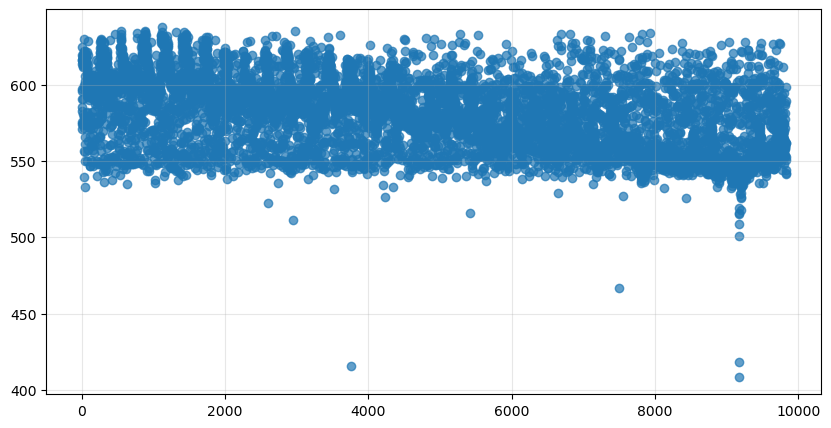

count    9829.000000
mean      578.636295
std        22.576476
min       408.599386
25%       559.357007
50%       579.361082
75%       595.569759
max       637.895790
Name: CO2_ElectroChemicalSensor, dtype: float64

In [34]:
plot_scatter(df["CO2_ElectroChemicalSensor"])
df["CO2_ElectroChemicalSensor"].describe()

MetalOxideSensor_Unit1 Column (WIP)

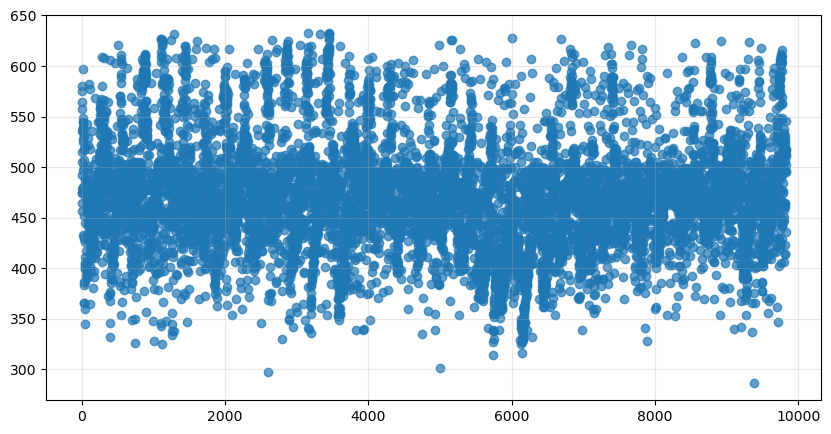

count    9829.000000
mean      470.984757
std        51.487102
min       286.825662
25%       440.102481
50%       469.147229
75%       494.783365
max       632.891693
Name: MetalOxideSensor_Unit1, dtype: float64

In [35]:
plot_scatter(df["MetalOxideSensor_Unit1"])
df["MetalOxideSensor_Unit1"].describe()

MetalOxideSensor_Unit2 Column (WIP)

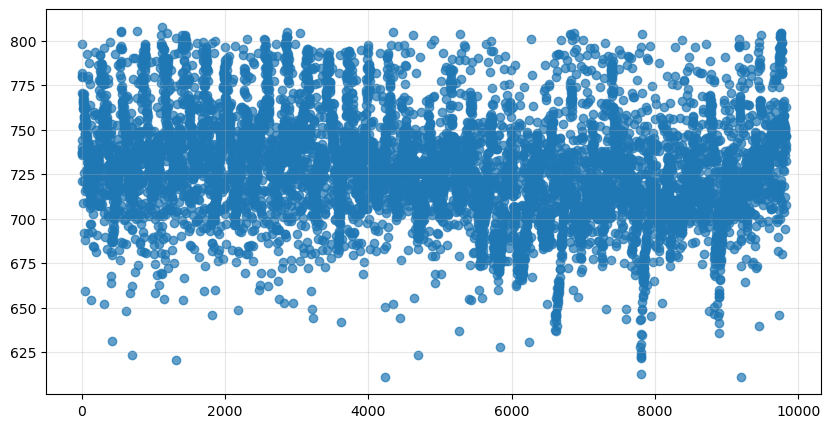

count    8423.000000
mean      728.379236
std        29.146617
min       611.168916
25%       709.657326
50%       726.780828
75%       745.029111
max       807.732943
Name: MetalOxideSensor_Unit2, dtype: float64

In [36]:
plot_scatter(df["MetalOxideSensor_Unit2"])
df["MetalOxideSensor_Unit2"].describe()

MetalOxideSensor_Unit3 Column (WIP)

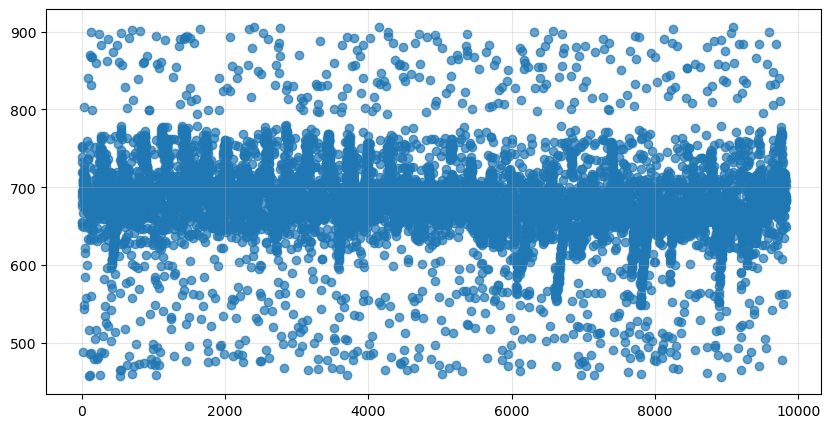

count    9829.000000
mean      680.493270
std        56.205247
min       456.673900
25%       658.480170
50%       679.857406
75%       703.593749
max       906.213097
Name: MetalOxideSensor_Unit3, dtype: float64

In [37]:
plot_scatter(df["MetalOxideSensor_Unit3"])
df["MetalOxideSensor_Unit3"].describe()

MetalOxideSensor_Unit4 Column (WIP)

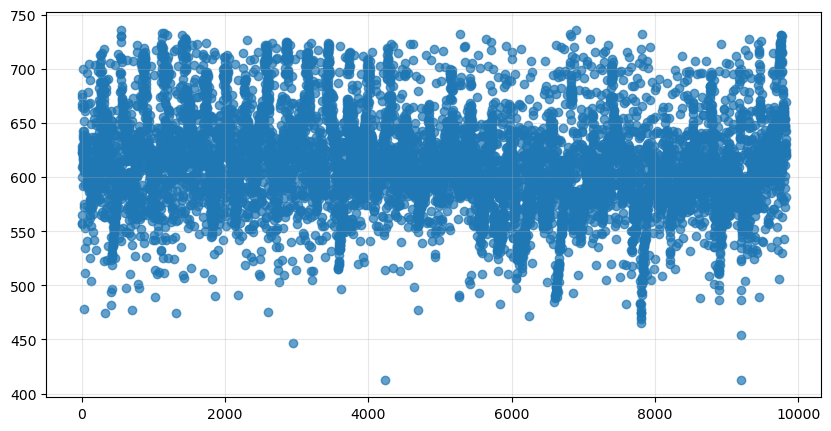

count    9829.000000
mean      612.271345
std        43.174539
min       412.791904
25%       585.441906
50%       609.492784
75%       636.177403
max       736.112361
Name: MetalOxideSensor_Unit4, dtype: float64

In [38]:
plot_scatter(df["MetalOxideSensor_Unit4"])
df["MetalOxideSensor_Unit4"].describe()

CO_GasSensor Column (WIP)

In [39]:
df["CO_GasSensor"].value_counts(dropna=False)

CO_GasSensor
1.0    4631
2.0    2702
0.0    1170
NaN     830
3.0     424
4.0      72
Name: count, dtype: int64

Session ID Column

In [40]:
df["Session ID"].value_counts()

Session ID
6528    382
4703    377
3418    363
1374    355
5820    353
7058    344
3592    337
2105    335
2847    331
3856    330
8936    305
7395    304
1903    299
4507    297
1826    279
9385    273
2679    272
9658    262
4129    255
5693    246
9127    244
6431    240
8052    239
7241    237
9184    236
9241    234
3074    231
7963    229
8374    209
5172    193
6817    192
4761    176
1458    175
6847    170
5214    167
1482    159
8649    143
2586     56
Name: count, dtype: int64

HVAC Operation Mode Column

In [41]:
df["HVAC Operation Mode"].value_counts()

HVAC Operation Mode
cooling_active      1474
maintenance_mode    1468
heating_active      1439
off                 1434
eco_mode            1422
ventilation_only    1366
COOLING_ACTIVE       112
ECO_MODE             112
MAINTENANCE_MODE     105
Off                  103
HEATING_ACTIVE        98
VENTILATION_ONLY      97
OFF                   93
Cooling_Active        64
Eco_mode              56
Eco_Mode              53
Heating_active        50
Cooling_active        50
Maintenance_Mode      49
Maintenance_mode      48
Ventilation_Only      47
Ventilation_only      45
Heating_Active        44
Name: count, dtype: int64

In [42]:
# standardise values to lower case
df["HVAC Operation Mode"] = df["HVAC Operation Mode"].apply(lambda x: x.lower())
df["HVAC Operation Mode"].value_counts()

HVAC Operation Mode
cooling_active      1700
maintenance_mode    1670
eco_mode            1643
heating_active      1631
off                 1630
ventilation_only    1555
Name: count, dtype: int64

Ambient Light Level Column (WIP)

In [43]:
df["Ambient Light Level"].value_counts(dropna=False)

Ambient Light Level
very_bright    3317
bright         2655
moderate       1429
None           1052
dim             852
very_dim        524
Name: count, dtype: int64

Activity Level Column

In [44]:
df["Activity Level"].value_counts()

Activity Level
Low Activity         5146
Moderate Activity    2765
High Activity        1070
ModerateActivity      325
Low_Activity          285
LowActivity           238
Name: count, dtype: int64

In [45]:
# Standardise activity level labels
standardised = {
    'Low Activity': 'low_activity',
    'LowActivity': 'low_activity',
    'Low_Activity': 'low_activity',
    'Moderate Activity': 'moderate_activity',
    'ModerateActivity': 'moderate_activity',
    'High Activity': 'high_activity',
}
df["Activity Level"] = df["Activity Level"].replace(standardised)
df["Activity Level"].value_counts(dropna=False)

Activity Level
low_activity         5669
moderate_activity    3090
high_activity        1070
Name: count, dtype: int64